In [27]:
# audio_analysis_fixed_path.py
# -------------------------------------------------------------
# Loads a specific audio file,
# extracts rhythm and tonal features using librosa,
# and prints a structured analysis report.
# -------------------------------------------------------------

import numpy as np
import librosa

# -------------------------------------------------------------
# FIXED AUDIO PATH
# -------------------------------------------------------------
audio_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

print("\n🎵 Analyzing file:", audio_path)

# -------------------------------------------------------------
# LOAD AUDIO
# -------------------------------------------------------------
y, sr = librosa.load(audio_path, sr=None)

duration_seconds = len(y) / sr

print("\n--- BASIC INFO ---")
print(f"Sample Rate: {sr}")
print(f"Duration: {duration_seconds:.2f} seconds")
print(f"Total Samples: {len(y)}")

# -------------------------------------------------------------
# TEMPO + BEAT TRACKING
# -------------------------------------------------------------
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames")
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

# Handle tempo array case
if isinstance(tempo, (list, np.ndarray)):
    tempo_value = float(np.mean(tempo))
else:
    tempo_value = float(tempo)

print("\n--- TEMPO & BEATS ---")
print(f"Estimated Tempo (BPM): {tempo_value:.2f}")
print(f"Number of Beats Detected: {len(beat_times)}")
print("First 10 Beat Times (seconds):", beat_times[:10])

# -------------------------------------------------------------
# ONSET DETECTION
# -------------------------------------------------------------
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

print("\n--- ONSETS ---")
print(f"Number of Onsets: {len(onset_times)}")
print("First 10 Onset Times (seconds):", onset_times[:10])

# -------------------------------------------------------------
# MFCC (TIMBRE FEATURES)
# -------------------------------------------------------------
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("\n--- MFCC ---")
print("MFCC shape (coefficients x frames):", mfcc.shape)
print("First MFCC vector:", mfcc[:, 0])

# -------------------------------------------------------------
# SPECTRAL FEATURES
# -------------------------------------------------------------
spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
spectral_flux = librosa.onset.onset_strength(y=y, sr=sr)

print("\n--- SPECTRAL FEATURES ---")
print("Mean Spectral Centroid:", float(np.mean(spectral_centroid)))
print("Mean Spectral Flux:", float(np.mean(spectral_flux)))

# -------------------------------------------------------------
# HARMONIC / PERCUSSIVE ENERGY
# -------------------------------------------------------------
harmonic, percussive = librosa.effects.hpss(y)

harmonic_rms = float(np.sqrt(np.mean(harmonic**2)))
percussive_rms = float(np.sqrt(np.mean(percussive**2)))

print("\n--- HARMONIC / PERCUSSIVE ENERGY ---")
print(f"Harmonic RMS: {harmonic_rms:.4f}")
print(f"Percussive RMS: {percussive_rms:.4f}")

# -------------------------------------------------------------
print("\n--------------------------------------------------")
print("Analysis complete.")
print("You now have: tempo, beats, onsets, MFCC, spectral features.")
print("--------------------------------------------------\n")



🎵 Analyzing file: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3

--- BASIC INFO ---
Sample Rate: 44100
Duration: 236.72 seconds
Total Samples: 10439471

--- TEMPO & BEATS ---
Estimated Tempo (BPM): 99.38
Number of Beats Detected: 376
First 10 Beat Times (seconds): [3.9938322  4.58594104 5.17804989 5.77015873 6.36226757 6.95437642
 7.52326531 8.11537415 8.70748299 9.29959184]

--- ONSETS ---
Number of Onsets: 457
First 10 Onset Times (seconds): [3.9938322  4.1447619  4.20281179 6.44353741 6.87310658 6.94276644
 6.98920635 7.05886621 9.61306122 9.89170068]

--- MFCC ---
MFCC shape (coefficients x frames): (13, 20390)
First MFCC vector: [-543.5068    0.        0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.        0.    ]

--- SPECTRAL FEATURES ---
Mean Spectral Centroid: 2233.7431800041086
Mean Spectral Flux: 0.9148837924003601

--- HARMONIC / PERCUSSIVE ENERGY ---
Harmonic RMS: 0.0936
Percussive RMS: 0.0215

---------

In [26]:
!pip install librosa soundfile


   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 14.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 16.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------ --------------------- 3.7/8.0 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 17.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/38.1 MB 18.4 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/38.1 MB 18.3 MB/s eta 0:00:02
   ------------ --------------------------- 11.8/38.1 MB 18.3 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/38.1 MB 18.3 MB/s eta 0:00:02
   -------------------- 


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# rhythm_vertical_lines_rewrite.py
# -------------------------------------------------------------
# Static rhythm visualization:
# - Detect beats from a given MP3
# - Compute beat durations
# - Draw vertical lines left-to-right
# - Line thickness = beat duration (normalized)
# - Save as a PNG (no animation)
# -------------------------------------------------------------

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# FIXED AUDIO PATH (your file)
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

# -------------------------------------------------------------
# OUTPUT
# -------------------------------------------------------------
output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "rhythm_vertical_lines.png")

print("\n🎵 Using audio:", mp3_path)

# -------------------------------------------------------------
# LOAD AUDIO (robust)
# -------------------------------------------------------------
try:
    import soundfile as sf
    y, sr = sf.read(mp3_path, always_2d=False)
    if getattr(y, "ndim", 1) == 2:     # stereo -> mono
        y = y.mean(axis=1)
    y = y.astype(np.float32)
except Exception as e:
    print("⚠️ soundfile failed, fallback to librosa:", repr(e))
    y, sr = librosa.load(mp3_path, sr=None)

# -------------------------------------------------------------
# BEAT TRACKING
# -------------------------------------------------------------
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames")
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected to build line sequence.")

# Beat durations (time between beats)
durations = np.diff(beat_times)
avg_dur = float(np.mean(durations))
durations = np.concatenate([durations, [avg_dur]])  # add last duration

# -------------------------------------------------------------
# MAP DURATION -> THICKNESS
# -------------------------------------------------------------
d_min, d_max = float(durations.min()), float(durations.max())
if abs(d_max - d_min) < 1e-9:
    norm = np.zeros_like(durations)
else:
    norm = (durations - d_min) / (d_max - d_min)

# thickness range (thin -> thick)
thicknesses = 0.3 + norm * 3.0

# -------------------------------------------------------------
# LINE POSITIONS
# -------------------------------------------------------------
spacing = 0.12  # adjust tighter/looser
x_positions = np.arange(len(thicknesses)) * spacing

# -------------------------------------------------------------
# DRAW
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(24, 5))
ax.set_facecolor("white")
ax.axis("off")

for x, lw in zip(x_positions, thicknesses):
    ax.plot([x, x], [-1, 1], color="black", linewidth=float(lw))

plt.savefig(output_path, dpi=200, bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

print("✅ Saved image to:", output_path)
print("Beats:", len(beat_times))



🎵 Using audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
✅ Saved image to: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output\rhythm_vertical_lines.png
Beats: 376


In [29]:
# rhythm_animation_frames_rewrite.py
# -------------------------------------------------------------
# Animation where vertical lines appear beat-by-beat, synced to music.
# This version SAVES frames to disk first, then builds an MP4 with audio.
# (Matches the teacher's approach closely.)
# -------------------------------------------------------------

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from moviepy.editor import AudioFileClip, ImageSequenceClip

# -------------------------------------------------------------
# FIXED AUDIO PATH
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

# -------------------------------------------------------------
# OUTPUT FOLDER
# -------------------------------------------------------------
output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music"
frames_folder = os.path.join(output_folder, "frames")
os.makedirs(frames_folder, exist_ok=True)

print("\n🎵 Using audio:", mp3_path)

# -------------------------------------------------------------
# LOAD AUDIO (robust)
# -------------------------------------------------------------
try:
    import soundfile as sf
    y, sr = sf.read(mp3_path, always_2d=False)
    if getattr(y, "ndim", 1) == 2:
        y = y.mean(axis=1)
    y = y.astype(np.float32)
except Exception as e:
    print("⚠️ soundfile failed, fallback to librosa:", repr(e))
    y, sr = librosa.load(mp3_path, sr=None)

# -------------------------------------------------------------
# BEAT TRACKING
# -------------------------------------------------------------
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames")
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected to animate.")

# Beat durations -> thickness
durations = np.diff(beat_times)
avg_dur = float(np.mean(durations))
durations = np.concatenate([durations, [avg_dur]])

d_min, d_max = float(durations.min()), float(durations.max())
norm = (durations - d_min) / (d_max - d_min + 1e-9)
thicknesses = 0.3 + norm * 3.0

# X positions
spacing = 0.12
x_positions = np.arange(len(beat_times)) * spacing

# -------------------------------------------------------------
# GENERATE FRAMES
# -------------------------------------------------------------
frames = []
print("🖼 Generating frames...")

for i in range(len(beat_times)):
    fig, ax = plt.subplots(figsize=(20, 4))
    ax.set_facecolor("white")
    ax.axis("off")

    # draw lines up to i
    for j in range(i + 1):
        x = float(x_positions[j])
        lw = float(thicknesses[j])
        ax.plot([x, x], [-1, 1], color="black", linewidth=lw)

    frame_path = os.path.join(frames_folder, f"frame_{i:05d}.png")
    plt.savefig(frame_path, dpi=120, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)

    frames.append(frame_path)

print("✅ Frames saved:", len(frames))
print("📁 Frames folder:", frames_folder)

# -------------------------------------------------------------
# BUILD VIDEO (FPS from average beat interval)
# -------------------------------------------------------------
beat_intervals = np.diff(beat_times)
mean_interval = float(np.mean(beat_intervals)) if len(beat_intervals) else 0.1
fps = max(1, int(round(1.0 / mean_interval)))  # keep reasonable fps

print(f"🎬 Building video at ~{fps} FPS...")

clip = ImageSequenceClip(frames, fps=fps)

# Attach audio
audio = AudioFileClip(mp3_path)
clip = clip.set_audio(audio)

output_path = os.path.join(output_folder, "rhythm_vertical_animation.mp4")
clip.write_videofile(output_path, codec="libx264", audio_codec="aac")

print("\n🎉 Saved video to:")
print(output_path)



🎵 Using audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Generating frames...
✅ Frames saved: 376
📁 Frames folder: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\frames
🎬 Building video at ~2 FPS...
Moviepy - Building video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_animation.mp4.
MoviePy - Writing audio in rhythm_vertical_animationTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_animation.mp4



Moviepy - Done !
Moviepy - video ready D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_animation.mp4

🎉 Saved video to:
D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_animation.mp4



🎵 Using: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
Moviepy - Building video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_NEW.mp4.
MoviePy - Writing audio in rhythm_vertical_tone_animation_NEWTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_NEW.mp4



t:  95%|█████████████████████████████████████████████████████████████▉   | 6768/7103 [13:37<01:06,  5.07it/s, now=None]

MemoryError: bad allocation

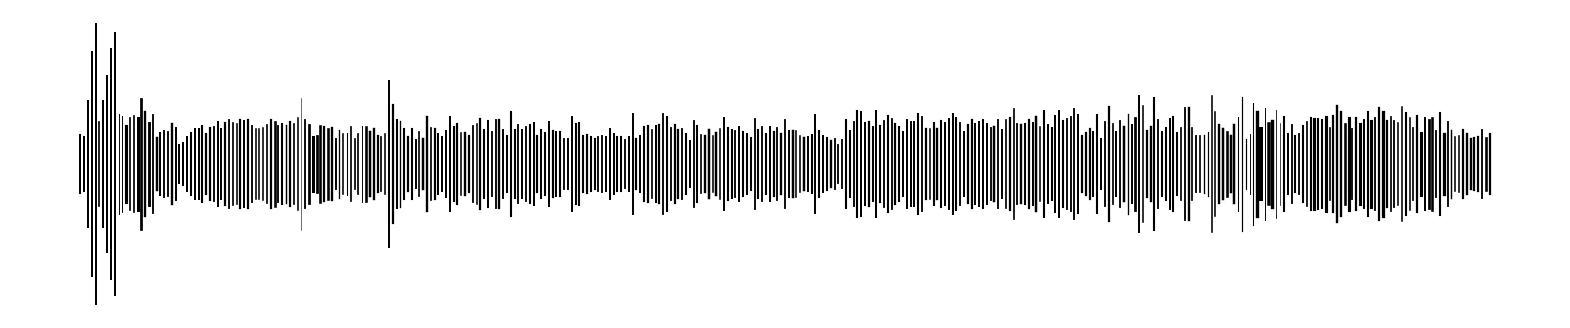

In [30]:
# rhythm_animation_tones_noframes_rewrite.py
# -------------------------------------------------------------
# No-frame-saving animation:
# - Lines appear in sync with beat times
# - Thickness = beat duration
# - Height = spectral centroid (tonal brightness) at each beat
# - Exports MP4 with audio embedded
# -------------------------------------------------------------

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from moviepy.editor import AudioFileClip, VideoClip

# -------------------------------------------------------------
# FIXED AUDIO PATH
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

# -------------------------------------------------------------
# OUTPUT
# -------------------------------------------------------------
output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "rhythm_vertical_tone_animation_NEW.mp4")

print("\n🎵 Using:", mp3_path)

# -------------------------------------------------------------
# LOAD AUDIO (robust)
# -------------------------------------------------------------
try:
    import soundfile as sf
    y, sr = sf.read(mp3_path, always_2d=False)
    if getattr(y, "ndim", 1) == 2:
        y = y.mean(axis=1)
    y = y.astype(np.float32)
except Exception as e:
    print("⚠️ soundfile failed, fallback to librosa:", repr(e))
    y, sr = librosa.load(mp3_path, sr=None)

# -------------------------------------------------------------
# BEATS
# -------------------------------------------------------------
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames")
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected to animate.")

# Beat durations -> thickness
durations = np.diff(beat_times)
avg_dur = float(np.mean(durations)) if len(durations) else 0.5
durations = np.concatenate([durations, [avg_dur]])

d_min, d_max = float(durations.min()), float(durations.max())
dur_norm = (durations - d_min) / (d_max - d_min + 1e-9)
thicknesses = 0.4 + dur_norm * 2.5

# -------------------------------------------------------------
# TONE (Spectral Centroid) -> Height at each beat
# -------------------------------------------------------------
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr)

heights = []
for bt in beat_times:
    idx = int(np.argmin(np.abs(centroid_times - bt)))
    heights.append(float(centroid[idx]))
heights = np.array(heights, dtype=float)

h_min, h_max = float(heights.min()), float(heights.max())
h_norm = (heights - h_min) / (h_max - h_min + 1e-9)
line_heights = 0.15 + h_norm * 0.95   # final height range

# -------------------------------------------------------------
# POSITIONS
# -------------------------------------------------------------
spacing = 0.12
x_positions = np.arange(len(beat_times)) * spacing

# -------------------------------------------------------------
# MAKE FRAME
# -------------------------------------------------------------
def make_frame(t):
    fig, ax = plt.subplots(figsize=(20, 4))
    ax.set_facecolor("white")
    ax.axis("off")

    # draw lines up to current time t
    for i, bt in enumerate(beat_times):
        if bt <= t:
            x = float(x_positions[i])
            lw = float(thicknesses[i])
            hh = float(line_heights[i])
            ax.plot([x, x], [-hh, hh], color="black", linewidth=lw)

    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    rgb = rgba[:, :, :3].copy()
    plt.close(fig)
    return rgb

# -------------------------------------------------------------
# VIDEO + AUDIO
# -------------------------------------------------------------
audio_clip = AudioFileClip(mp3_path)
video = VideoClip(make_frame, duration=audio_clip.duration).set_audio(audio_clip)

video.write_videofile(output_path, fps=30, codec="libx264", audio_codec="aac")

print("\n🎉 Saved animation to:")
print(output_path)


In [31]:
# rhythm_animation_tones_noframes_memorysafe.py
# -------------------------------------------------------------
# No-frame-saving animation (memory-safe):
# - Reuse ONE matplotlib figure
# - Use LineCollection for efficient drawing
# - Thickness = beat duration
# - Height = spectral centroid at beat
# - Exports MP4 with audio
# -------------------------------------------------------------

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from moviepy.editor import AudioFileClip, VideoClip

# -------------------------------------------------------------
# FIXED AUDIO PATH
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

# -------------------------------------------------------------
# OUTPUT
# -------------------------------------------------------------
output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "rhythm_vertical_tone_animation_NEW.mp4")

print("\n🎵 Using:", mp3_path)

# -------------------------------------------------------------
# LOAD AUDIO (robust)
# -------------------------------------------------------------
try:
    import soundfile as sf
    y, sr = sf.read(mp3_path, always_2d=False)
    if getattr(y, "ndim", 1) == 2:
        y = y.mean(axis=1)
    y = y.astype(np.float32)
except Exception as e:
    print("⚠️ soundfile failed, fallback to librosa:", repr(e))
    y, sr = librosa.load(mp3_path, sr=None)

# -------------------------------------------------------------
# BEATS
# -------------------------------------------------------------
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames")
beat_times = librosa.frames_to_time(beat_frames, sr=sr)
if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected.")

# durations -> thickness
durations = np.diff(beat_times)
avg_dur = float(np.mean(durations)) if len(durations) else 0.5
durations = np.concatenate([durations, [avg_dur]])

d_min, d_max = float(durations.min()), float(durations.max())
dur_norm = (durations - d_min) / (d_max - d_min + 1e-9)
thicknesses = 0.4 + dur_norm * 2.5  # linewidths

# -------------------------------------------------------------
# TONE -> HEIGHT
# -------------------------------------------------------------
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr)

heights = np.array(
    [float(centroid[int(np.argmin(np.abs(centroid_times - bt)))]) for bt in beat_times],
    dtype=float
)

h_min, h_max = float(heights.min()), float(heights.max())
h_norm = (heights - h_min) / (h_max - h_min + 1e-9)
line_heights = 0.15 + h_norm * 0.95

# -------------------------------------------------------------
# POSITIONS
# -------------------------------------------------------------
spacing = 0.12
x_positions = np.arange(len(beat_times)) * spacing

# Precompute line segments (x, -h) -> (x, +h)
segments = np.array(
    [[[x_positions[i], -line_heights[i]], [x_positions[i], line_heights[i]]]
     for i in range(len(beat_times))],
    dtype=float
)

# -------------------------------------------------------------
# ONE FIGURE, REUSED
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 4))
ax.set_facecolor("white")
ax.axis("off")

# fixed limits so the view doesn't jump
ax.set_xlim(-0.2, float(x_positions[-1]) + 0.2)
ax.set_ylim(-1.2, 1.2)

# Start with 0 lines
lc = LineCollection([], colors="black", linewidths=[])
ax.add_collection(lc)

# Render buffer size (RGB)
fig.canvas.draw()
W, H = fig.canvas.get_width_height()

# Map time -> how many beats have happened
# (uses searchsorted for speed)
def beat_count_at_time(t: float) -> int:
    return int(np.searchsorted(beat_times, t, side="right"))

def make_frame(t):
    n = beat_count_at_time(t)
    if n <= 0:
        lc.set_segments([])
        lc.set_linewidths([])
    else:
        lc.set_segments(segments[:n])
        lc.set_linewidths(thicknesses[:n])

    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[:, :, :3].copy()  # RGB for moviepy

# -------------------------------------------------------------
# VIDEO + AUDIO
# -------------------------------------------------------------
audio_clip = AudioFileClip(mp3_path)
video = VideoClip(make_frame, duration=audio_clip.duration).set_audio(audio_clip)

video.write_videofile(output_path, fps=30, codec="libx264", audio_codec="aac")

plt.close(fig)

print("\n🎉 Saved animation to:")
print(output_path)




🎵 Using: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3


MemoryError: Unable to allocate 224. MiB for an array with shape (1440, 20390) and data type float64

In [1]:
# rhythm_vertical_tone_animation_ULTRA_LOW_MEM.py
# -------------------------------------------------------------
# Ultra low memory, guaranteed-to-finish version:
# - Only 1 frame per BEAT (not 30fps continuous)
# - Video length still matches audio duration by setting fps accordingly
# - Reuse ONE matplotlib figure (no per-frame plt.subplots)
# - Very low resolution to reduce memory and temp usage
# -------------------------------------------------------------

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from moviepy.editor import AudioFileClip, ImageSequenceClip

# -------------------------------------------------------------
# PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "rhythm_vertical_tone_animation_LOW_MEM.mp4")

print("\n🎵 Using:", mp3_path)

# -------------------------------------------------------------
# LOAD AUDIO (fast/robust)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)  # ✅ downsample to reduce memory/time

# -------------------------------------------------------------
# BEATS (memory safer: larger hop_length)
# -------------------------------------------------------------
hop_length = 1024
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames", hop_length=hop_length)
beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)

if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected.")

# Durations -> thickness
durations = np.diff(beat_times)
avg_dur = float(np.mean(durations)) if len(durations) else 0.5
durations = np.concatenate([durations, [avg_dur]])

dur_norm = (durations - durations.min()) / (durations.max() - durations.min() + 1e-9)
thicknesses = 0.6 + dur_norm * 2.0  # keep simple

# -------------------------------------------------------------
# TONE -> HEIGHT (spectral centroid)
# -------------------------------------------------------------
centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr, hop_length=hop_length)

heights = np.array(
    [float(centroid[int(np.argmin(np.abs(centroid_times - bt)))]) for bt in beat_times],
    dtype=float
)
h_norm = (heights - heights.min()) / (heights.max() - heights.min() + 1e-9)
line_heights = 0.2 + h_norm * 0.9

# -------------------------------------------------------------
# POSITIONS
# -------------------------------------------------------------
spacing = 0.12
x_positions = np.arange(len(beat_times)) * spacing

segments_all = np.array(
    [[[x_positions[i], -line_heights[i]], [x_positions[i], line_heights[i]]]
     for i in range(len(beat_times))],
    dtype=float
)

# -------------------------------------------------------------
# RENDER BEAT-FRAMES INTO MEMORY (ONLY 376 frames)
# -------------------------------------------------------------
# ✅ tiny canvas => very low memory
fig, ax = plt.subplots(figsize=(10, 2), dpi=80)  # small output
ax.set_facecolor("white")
ax.axis("off")
ax.set_xlim(-0.2, float(x_positions[-1]) + 0.2)
ax.set_ylim(-1.2, 1.2)

lc = LineCollection([], colors="black", linewidths=[])
ax.add_collection(lc)

frames_rgb = []
print("🖼 Rendering 1 frame per beat:", len(beat_times))

for i in range(len(beat_times)):
    lc.set_segments(segments_all[: i + 1])
    lc.set_linewidths(thicknesses[: i + 1])

    fig.canvas.draw()
    rgb = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
    frames_rgb.append(rgb)

plt.close(fig)
print("✅ Beat-frames ready:", len(frames_rgb))

# -------------------------------------------------------------
# BUILD VIDEO
# -------------------------------------------------------------
audio = AudioFileClip(mp3_path)
duration = audio.duration

# fps chosen so total frames stretch across full audio duration
fps = len(frames_rgb) / duration
print(f"🎬 Building video at fps={fps:.3f} (so length matches audio)")

clip = ImageSequenceClip(frames_rgb, fps=fps).set_audio(audio)

# ✅ Make FFmpeg temp go to D: (reduces C: damage)
temp_audio = os.path.join(output_folder, "TEMP_AUDIO.m4a")
clip.write_videofile(
    output_path,
    codec="libx264",
    audio_codec="aac",
    temp_audiofile=temp_audio,
    remove_temp=True
)

print("\n🎉 Saved:", output_path)



🎵 Using: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Rendering 1 frame per beat: 375
✅ Beat-frames ready: 375
🎬 Building video at fps=1.584 (so length matches audio)
Moviepy - Building video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_LOW_MEM.mp4.
MoviePy - Writing audio in D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\TEMP_AUDIO.m4a


MoviePy - Done.
Moviepy - Writing video D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_LOW_MEM.mp4



Moviepy - Done !
Moviepy - video ready D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_LOW_MEM.mp4

🎉 Saved: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_music\rhythm_vertical_tone_animation_LOW_MEM.mp4


In [2]:
# distort_image_by_tone_horizontal_LOW_MEM.py
# -------------------------------------------------------------
# Distort ONE image using horizontal wave displacement driven by
# tonal brightness (spectral centroid) of an MP3.
# Ultra-safe: no slicing, no video, low memory.
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"

input_image_folder = r"C:\Users\ioana\OneDrive\Desktop\Bartlett\RC11\2025-2026\Digital Skills\1\Workshop_8\inputs\input_image"
# ↑ 如果你不用这个老师文件夹，改成你自己的图片文件夹（只要里面有一张 png/jpg）

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "distorted_by_tone_horizontal.png")

# -------------------------------------------------------------
# FIND FIRST IMAGE
# -------------------------------------------------------------
img_files = [f for f in os.listdir(input_image_folder)
             if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))]
if not img_files:
    raise FileNotFoundError(f"No image found in: {input_image_folder}")

img_files.sort()
img_path = os.path.join(input_image_folder, img_files[0])

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO -> TONE CURVE (low memory)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)     # downsample
hop_length = 2048                             # fewer frames

centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
tone = centroid.astype(np.float32)

# normalize 0..1
t_min, t_max = float(tone.min()), float(tone.max())
tone = (tone - t_min) / (t_max - t_min + 1e-9)

# smooth (moving average)
k = 11
if len(tone) >= k:
    tone = np.convolve(tone, np.ones(k, dtype=np.float32) / k, mode="same")

# -------------------------------------------------------------
# LOAD IMAGE (optional: make it smaller to be extra safe)
# -------------------------------------------------------------
img = Image.open(img_path).convert("RGB")

# ✅ 如果你想更省内存/更快：把最长边缩到 1200
max_side = 1200
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))
w, h = img.size

arr = np.array(img, dtype=np.uint8)

# -------------------------------------------------------------
# MAP TONE -> EACH ROW (horizontal distortion)
# -------------------------------------------------------------
tone_per_row = np.interp(
    np.arange(h),
    np.linspace(0, h - 1, len(tone)),
    tone
).astype(np.float32)

# distortion controls (轻微即可)
max_shift_pixels = 18        # 失真强度（越大越扭）
base_freq = 10.0             # 波纹基础频率（越大越平缓）
extra_freq = 18.0            # tone高时频率变化

amp_map = tone_per_row * max_shift_pixels
freq_map = base_freq + tone_per_row * extra_freq

# -------------------------------------------------------------
# APPLY DISTORTION
# -------------------------------------------------------------
distorted = np.empty_like(arr)

for yy in range(h):
    amp = float(amp_map[yy])
    freq = float(freq_map[yy])

    # shift each pixel by sampling from a shifted x
    for xx in range(w):
        shift = int(math.sin(xx / max(freq, 1e-6)) * amp)
        sx = min(w - 1, max(0, xx + shift))
        distorted[yy, xx] = arr[yy, sx]

# -------------------------------------------------------------
# SAVE
# -------------------------------------------------------------
out_img = Image.fromarray(distorted)
out_img.save(output_path)

print("✅ Saved:", output_path)


FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'C:\\Users\\ioana\\OneDrive\\Desktop\\Bartlett\\RC11\\2025-2026\\Digital Skills\\1\\Workshop_8\\inputs\\input_image'

In [3]:
# distort_image_by_tone_horizontal_FIXED_IMAGE.py
# -------------------------------------------------------------
# Distort ONE fixed image using horizontal wave displacement driven by
# tonal brightness (spectral centroid) of an MP3.
# Low memory, guaranteed output.
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# FIXED PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
img_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG"

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "distorted_by_tone_horizontal.png")

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO -> TONE CURVE (low memory)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)   # downsample
hop_length = 2048                          # fewer frames

centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0].astype(np.float32)

# normalize to 0..1
c_min, c_max = float(centroid.min()), float(centroid.max())
tone = (centroid - c_min) / (c_max - c_min + 1e-9)

# smooth (moving average)
k = 11
if len(tone) >= k:
    tone = np.convolve(tone, np.ones(k, dtype=np.float32) / k, mode="same")

# -------------------------------------------------------------
# LOAD IMAGE (optional resize to be safer)
# -------------------------------------------------------------
img = Image.open(img_path).convert("RGB")

max_side = 1200  # lower this (e.g. 800) if you want even faster
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))

w, h = img.size
arr = np.array(img, dtype=np.uint8)

# -------------------------------------------------------------
# MAP TONE -> EACH ROW (horizontal distortion)
# -------------------------------------------------------------
tone_per_row = np.interp(
    np.arange(h),
    np.linspace(0, h - 1, len(tone)),
    tone
).astype(np.float32)

# distortion controls (mild)
max_shift_pixels = 18   # strength
base_freq = 10.0        # wave smoothness
extra_freq = 18.0       # variation with tone

amp_map = tone_per_row * max_shift_pixels
freq_map = base_freq + tone_per_row * extra_freq

# -------------------------------------------------------------
# APPLY DISTORTION
# -------------------------------------------------------------
distorted = np.empty_like(arr)

for yy in range(h):
    amp = float(amp_map[yy])
    freq = float(freq_map[yy])

    for xx in range(w):
        shift = int(math.sin(xx / max(freq, 1e-6)) * amp)
        sx = min(w - 1, max(0, xx + shift))
        distorted[yy, xx] = arr[yy, sx]

# -------------------------------------------------------------
# SAVE
# -------------------------------------------------------------
Image.fromarray(distorted).save(output_path)
print("✅ Saved:", output_path)


🎵 Audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Image: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG
✅ Saved: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image\distorted_by_tone_horizontal.png


In [4]:
# distort_image_glitch_bw_stronger.py
# -------------------------------------------------------------
# Black & white "glitch photo" distortion driven by MP3 tone.
# - Tone feature: spectral centroid (normalized + smoothed)
# - Distortion: horizontal wave displacement per row
# - Style: grayscale + higher contrast + light noise
# - Stronger wave distortion (bigger max shift)
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# FIXED PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
img_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG"

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "distorted_glitch_bw_stronger.png")

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO -> TONE CURVE (low memory)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)     # downsample
hop_length = 2048                             # fewer frames -> faster/less memory

centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0].astype(np.float32)

# normalize tone to 0..1
c_min, c_max = float(centroid.min()), float(centroid.max())
tone = (centroid - c_min) / (c_max - c_min + 1e-9)

# smooth (moving average)
k = 11
if len(tone) >= k:
    tone = np.convolve(tone, np.ones(k, dtype=np.float32) / k, mode="same")

# -------------------------------------------------------------
# LOAD IMAGE -> BLACK/WHITE GLITCH LOOK
# -------------------------------------------------------------
img = Image.open(img_path).convert("L")  # grayscale

# Optional resize (keep memory safe)
max_side = 1400  # increase for bigger output; decrease (e.g. 900) for speed
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))

w, h = img.size

# Contrast stretch + noise (glitch vibe)
# - contrast: 1.6 (stronger)
# - noise sigma: 10 (stronger)
arr_gray = np.array(img, dtype=np.float32)
arr_gray = (arr_gray - 128.0) * 1.6 + 128.0
arr_gray += np.random.normal(0, 10, (h, w)).astype(np.float32)
arr_gray = np.clip(arr_gray, 0, 255).astype(np.uint8)

# make it RGB so saving is consistent
arr = np.stack([arr_gray, arr_gray, arr_gray], axis=-1)

# -------------------------------------------------------------
# MAP TONE -> EACH ROW (horizontal distortion)
# -------------------------------------------------------------
tone_per_row = np.interp(
    np.arange(h),
    np.linspace(0, h - 1, len(tone)),
    tone
).astype(np.float32)

# -------------------------------------------------------------
# DISTORTION CONTROLS (MAKE WAVES BIGGER)
# -------------------------------------------------------------
max_shift_pixels = 45   # ✅ bigger distortion (was ~18)
base_freq = 7.0         # ✅ smaller => more wavy
extra_freq = 14.0       # variation with tone

amp_map = tone_per_row * max_shift_pixels
freq_map = base_freq + tone_per_row * extra_freq

# -------------------------------------------------------------
# APPLY DISTORTION
# -------------------------------------------------------------
distorted = np.empty_like(arr)

for yy in range(h):
    amp = float(amp_map[yy])
    freq = float(freq_map[yy])

    for xx in range(w):
        shift = int(math.sin(xx / max(freq, 1e-6)) * amp)
        sx = min(w - 1, max(0, xx + shift))
        distorted[yy, xx] = arr[yy, sx]

# -------------------------------------------------------------
# SAVE
# -------------------------------------------------------------
Image.fromarray(distorted).save(output_path)
print("✅ Saved:", output_path)


🎵 Audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Image: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG
✅ Saved: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image\distorted_glitch_bw_stronger.png


In [5]:
# distort_image_glitch_bw_vertical_stronger.py
# -------------------------------------------------------------
# Black & white "glitch photo" distortion driven by MP3 tone.
# VERTICAL version:
# - Tone feature: spectral centroid (normalized + smoothed)
# - Distortion: vertical wave displacement per column (shift Y)
# - Style: grayscale + higher contrast + light noise
# - Stronger wave distortion
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# FIXED PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
img_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG"

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "distorted_glitch_bw_vertical_stronger.png")

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO -> TONE CURVE (low memory)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)     # downsample
hop_length = 2048                             # fewer frames

centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0].astype(np.float32)

# normalize tone to 0..1
c_min, c_max = float(centroid.min()), float(centroid.max())
tone = (centroid - c_min) / (c_max - c_min + 1e-9)

# smooth (moving average)
k = 11
if len(tone) >= k:
    tone = np.convolve(tone, np.ones(k, dtype=np.float32) / k, mode="same")

# -------------------------------------------------------------
# LOAD IMAGE -> BLACK/WHITE GLITCH LOOK
# -------------------------------------------------------------
img = Image.open(img_path).convert("L")  # grayscale

# Optional resize (memory safe)
max_side = 1400
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))

w, h = img.size

# Contrast stretch + noise
arr_gray = np.array(img, dtype=np.float32)
arr_gray = (arr_gray - 128.0) * 1.6 + 128.0
arr_gray += np.random.normal(0, 10, (h, w)).astype(np.float32)
arr_gray = np.clip(arr_gray, 0, 255).astype(np.uint8)

# Convert to RGB array for consistent output
arr = np.stack([arr_gray, arr_gray, arr_gray], axis=-1)

# -------------------------------------------------------------
# MAP TONE -> EACH COLUMN (vertical distortion)
# -------------------------------------------------------------
tone_per_col = np.interp(
    np.arange(w),
    np.linspace(0, w - 1, len(tone)),
    tone
).astype(np.float32)

# -------------------------------------------------------------
# DISTORTION CONTROLS (MAKE WAVES BIGGER)
# -------------------------------------------------------------
max_shift_pixels = 45   # bigger vertical distortion
base_freq = 7.0         # smaller => more wavy
extra_freq = 14.0

amp_map = tone_per_col * max_shift_pixels
freq_map = base_freq + tone_per_col * extra_freq

# -------------------------------------------------------------
# APPLY VERTICAL DISTORTION
# (sample from shifted Y: arr[new_y, x])
# -------------------------------------------------------------
distorted = np.empty_like(arr)

for xx in range(w):
    amp = float(amp_map[xx])
    freq = float(freq_map[xx])

    for yy in range(h):
        shift = int(math.sin(yy / max(freq, 1e-6)) * amp)
        sy = min(h - 1, max(0, yy + shift))
        distorted[yy, xx] = arr[sy, xx]

# -------------------------------------------------------------
# SAVE
# -------------------------------------------------------------
Image.fromarray(distorted).save(output_path)
print("✅ Saved:", output_path)


🎵 Audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Image: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG
✅ Saved: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image\distorted_glitch_bw_vertical_stronger.png


In [6]:
# distort_image_by_beats_slices_fixed.py
# -------------------------------------------------------------
# Slice-based distortion (one vertical slice per beat):
# - Beat times decide number of vertical slices
# - Spectral centroid at each beat decides distortion strength
# - Uses linspace boundaries to avoid the "white stripe" bug
# - Optional black/white glitch look
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
img_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG"

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "distorted_by_beats_slices.png")

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO (low memory)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)
hop_length = 1024

# beats
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, units="frames", hop_length=hop_length)
beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)

if len(beat_times) < 2:
    raise RuntimeError("Too few beats detected.")

# spectral centroid
centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr, hop_length=hop_length)

heights = np.array(
    [float(centroid[int(np.argmin(np.abs(centroid_times - bt)))]) for bt in beat_times],
    dtype=np.float32
)

# normalize 0..1
h_min, h_max = float(heights.min()), float(heights.max())
tone = (heights - h_min) / (h_max - h_min + 1e-9)

# -------------------------------------------------------------
# LOAD IMAGE (optional glitch look)
# -------------------------------------------------------------
img = Image.open(img_path).convert("L")  # grayscale
max_side = 1400
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))
w, h = img.size

arr = np.array(img, dtype=np.uint8)

# add slight contrast + noise (optional; comment out if unwanted)
arr_f = arr.astype(np.float32)
arr_f = (arr_f - 128.0) * 1.4 + 128.0
arr_f += np.random.normal(0, 6, (h, w)).astype(np.float32)
arr = np.clip(arr_f, 0, 255).astype(np.uint8)

# -------------------------------------------------------------
# CHOOSE SLICE COUNT
# -------------------------------------------------------------
# Using all beats can create hundreds of slices (slow).
# To keep it practical, limit to at most 220 slices.
max_slices = 220
num_slices = min(len(tone), max_slices)

# downsample tone to match num_slices
tone_idx = np.linspace(0, len(tone) - 1, num_slices).astype(int)
tone_slices = tone[tone_idx]

print("🧩 Slices:", num_slices)

# IMPORTANT: slice boundaries with linspace -> no white stripe
bounds = np.linspace(0, w, num_slices + 1).astype(int)

# -------------------------------------------------------------
# DISTORT EACH SLICE
# -------------------------------------------------------------
# stronger distortion control
base_amp = 2      # minimal shift
max_extra = 28    # extra shift when tone is high (increase for bigger waves)

distorted = np.empty_like(arr)

for i in range(num_slices):
    x1, x2 = bounds[i], bounds[i + 1]
    if x2 <= x1:
        continue

    slice_img = arr[:, x1:x2].copy()
    sw = slice_img.shape[1]

    t = float(tone_slices[i])              # 0..1
    amp = base_amp + t * max_extra         # pixels
    freq = 18.0 - t * 10.0                 # higher tone => tighter waves

    # wave shift each row within this slice
    for yy in range(h):
        shift = int(math.sin(yy / max(freq, 1e-6)) * amp)
        slice_img[yy] = np.roll(slice_img[yy], shift)

    distorted[:, x1:x2] = slice_img

# -------------------------------------------------------------
# SAVE (convert back to RGB for standard png)
# -------------------------------------------------------------
out_rgb = np.stack([distorted, distorted, distorted], axis=-1)
Image.fromarray(out_rgb).save(output_path)

print("✅ Saved:", output_path)


🎵 Audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Image: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG
🧩 Slices: 220
✅ Saved: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image\distorted_by_beats_slices.png


In [7]:
# distort_image_by_beats_slices_EXTREME.py
# -------------------------------------------------------------
# EXTREME SLICE DISTORTION VERSION
# - Beat-based vertical slices
# - VERY large wave displacement
# - Tight frequency (zigzag look)
# - Random slice offsets for glitch tearing
# -------------------------------------------------------------

import os
import math
import numpy as np
import librosa
from PIL import Image

# -------------------------------------------------------------
# PATHS
# -------------------------------------------------------------
mp3_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3"
img_path = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG"

output_folder = r"D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "distorted_EXTREME_slices.png")

print("🎵 Audio:", mp3_path)
print("🖼 Image:", img_path)

# -------------------------------------------------------------
# AUDIO (low memory safe)
# -------------------------------------------------------------
y, sr = librosa.load(mp3_path, sr=22050)
hop_length = 1024

tempo, beat_frames = librosa.beat.beat_track(
    y=y, sr=sr, units="frames", hop_length=hop_length
)
beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)

centroid = librosa.feature.spectral_centroid(
    y=y, sr=sr, hop_length=hop_length
)[0]
centroid_times = librosa.frames_to_time(
    np.arange(len(centroid)), sr=sr, hop_length=hop_length
)

heights = np.array(
    [float(centroid[int(np.argmin(np.abs(centroid_times - bt)))])
     for bt in beat_times],
    dtype=np.float32
)

h_min, h_max = float(heights.min()), float(heights.max())
tone = (heights - h_min) / (h_max - h_min + 1e-9)

# -------------------------------------------------------------
# IMAGE (black & white)
# -------------------------------------------------------------
img = Image.open(img_path).convert("L")

max_side = 1400
w, h = img.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)))

w, h = img.size
arr = np.array(img, dtype=np.uint8)

# Strong contrast + noise
arr_f = arr.astype(np.float32)
arr_f = (arr_f - 128.0) * 2.0 + 128.0
arr_f += np.random.normal(0, 15, (h, w)).astype(np.float32)
arr = np.clip(arr_f, 0, 255).astype(np.uint8)

# -------------------------------------------------------------
# SLICE SETUP
# -------------------------------------------------------------
max_slices = 260
num_slices = min(len(tone), max_slices)

tone_idx = np.linspace(0, len(tone) - 1, num_slices).astype(int)
tone_slices = tone[tone_idx]

bounds = np.linspace(0, w, num_slices + 1).astype(int)

print("🧩 Extreme slices:", num_slices)

# -------------------------------------------------------------
# EXTREME DISTORTION
# -------------------------------------------------------------
base_amp = 10           # minimum shift
max_extra = 90          # EXTREME amplitude
base_freq = 6.0         # small = tight zigzag
freq_variation = 20.0

distorted = np.empty_like(arr)

for i in range(num_slices):
    x1, x2 = bounds[i], bounds[i + 1]
    if x2 <= x1:
        continue

    slice_img = arr[:, x1:x2].copy()

    t = float(tone_slices[i])
    amp = base_amp + t * max_extra
    freq = base_freq + (1 - t) * freq_variation

    # Random full-slice vertical shift (glitch tearing)
    global_shift = np.random.randint(-30, 30)
    slice_img = np.roll(slice_img, global_shift, axis=0)

    # Per-row wave distortion
    for yy in range(h):
        shift = int(math.sin(yy / max(freq, 1e-6)) * amp)
        slice_img[yy] = np.roll(slice_img[yy], shift)

    distorted[:, x1:x2] = slice_img

# -------------------------------------------------------------
# SAVE
# -------------------------------------------------------------
out_rgb = np.stack([distorted, distorted, distorted], axis=-1)
Image.fromarray(out_rgb).save(output_path)

print("🔥 EXTREME distortion saved to:")
print(output_path)


🎵 Audio: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\mp3\中国交响乐团 - 春江花月夜.mp3
🖼 Image: D:\巴企蠕动中\skill 总\skill python\3.book drawing line\inputs\image\哥西.JPG
🧩 Extreme slices: 260
🔥 EXTREME distortion saved to:
D:\巴企蠕动中\skill 总\skill python\3.book drawing line\output_image\distorted_EXTREME_slices.png
